In [ ]:
ЭТО НЕ ВЗЛЕТЕЛО
/home/notai/Sandbox/a2k-procar/infra-local/streamlit/app.py

In [ ]:
# Устанавливаем нужные библиотеки
# mlflow - трекинг экспериментов
# seldon-core - клиент для деплоя
!pip install mlflow scikit-learn pandas numpy matplotlib seaborn -q

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline

import requests
import os
import json
import time

print("Все импорты успешны ✓")

Все импорты успешны ✓


In [2]:
# Генерируем данные о серверах
# Каждая строка = снимок метрик одного сервера за час
# Целевая переменная: failure (1 = сбой в течение 24ч, 0 = всё ок)

np.random.seed(42)
N = 2000  # количество наблюдений

def generate_server_metrics(n):
    # Нормальная работа (80% случаев)
    normal_n = int(n * 0.8)
    # Преддефолтное состояние (20% случаев)
    failure_n = n - normal_n

    normal = pd.DataFrame({
        'cpu_usage':        np.random.normal(45, 15, normal_n).clip(5, 95),
        'ram_usage':        np.random.normal(55, 20, normal_n).clip(10, 95),
        'disk_io':          np.random.normal(30, 10, normal_n).clip(0, 100),
        'network_errors':   np.random.poisson(2, normal_n),
        'temperature':      np.random.normal(55, 5, normal_n).clip(30, 90),
        'uptime_days':      np.random.exponential(30, normal_n).clip(0, 365),
        'failed_requests':  np.random.poisson(5, normal_n),
        'failure': 0
    })

    # У предсбойных серверов метрики хуже
    failure = pd.DataFrame({
        'cpu_usage':        np.random.normal(80, 10, failure_n).clip(50, 100),
        'ram_usage':        np.random.normal(85, 10, failure_n).clip(60, 100),
        'disk_io':          np.random.normal(75, 15, failure_n).clip(30, 100),
        'network_errors':   np.random.poisson(20, failure_n),
        'temperature':      np.random.normal(75, 8, failure_n).clip(50, 95),
        'uptime_days':      np.random.exponential(60, failure_n).clip(0, 365),
        'failed_requests':  np.random.poisson(50, failure_n),
        'failure': 1
    })

    df = pd.concat([normal, failure]).sample(frac=1).reset_index(drop=True)
    return df

df = generate_server_metrics(N)
print(f"Датасет: {df.shape}")
print(f"Распределение классов:\n{df['failure'].value_counts()}")
df.head()

Датасет: (2000, 8)
Распределение классов:
failure
0    1600
1     400
Name: count, dtype: int64


,cpu_usage,ram_usage,disk_io,network_errors,temperature,uptime_days,failed_requests,failure
0,63.938762,57.871759,25.170902,4,60.959780,2.971834,8,0
1,49.028884,10.000000,1.624936,2,53.878954,35.071698,5,0
2,42.095108,49.337222,35.925303,1,57.977295,55.714864,5,0
3,62.412402,30.349534,10.044682,3,60.681714,2.183464,11,0
4,51.201524,35.871272,21.072125,3,58.510053,17.527219,3,0


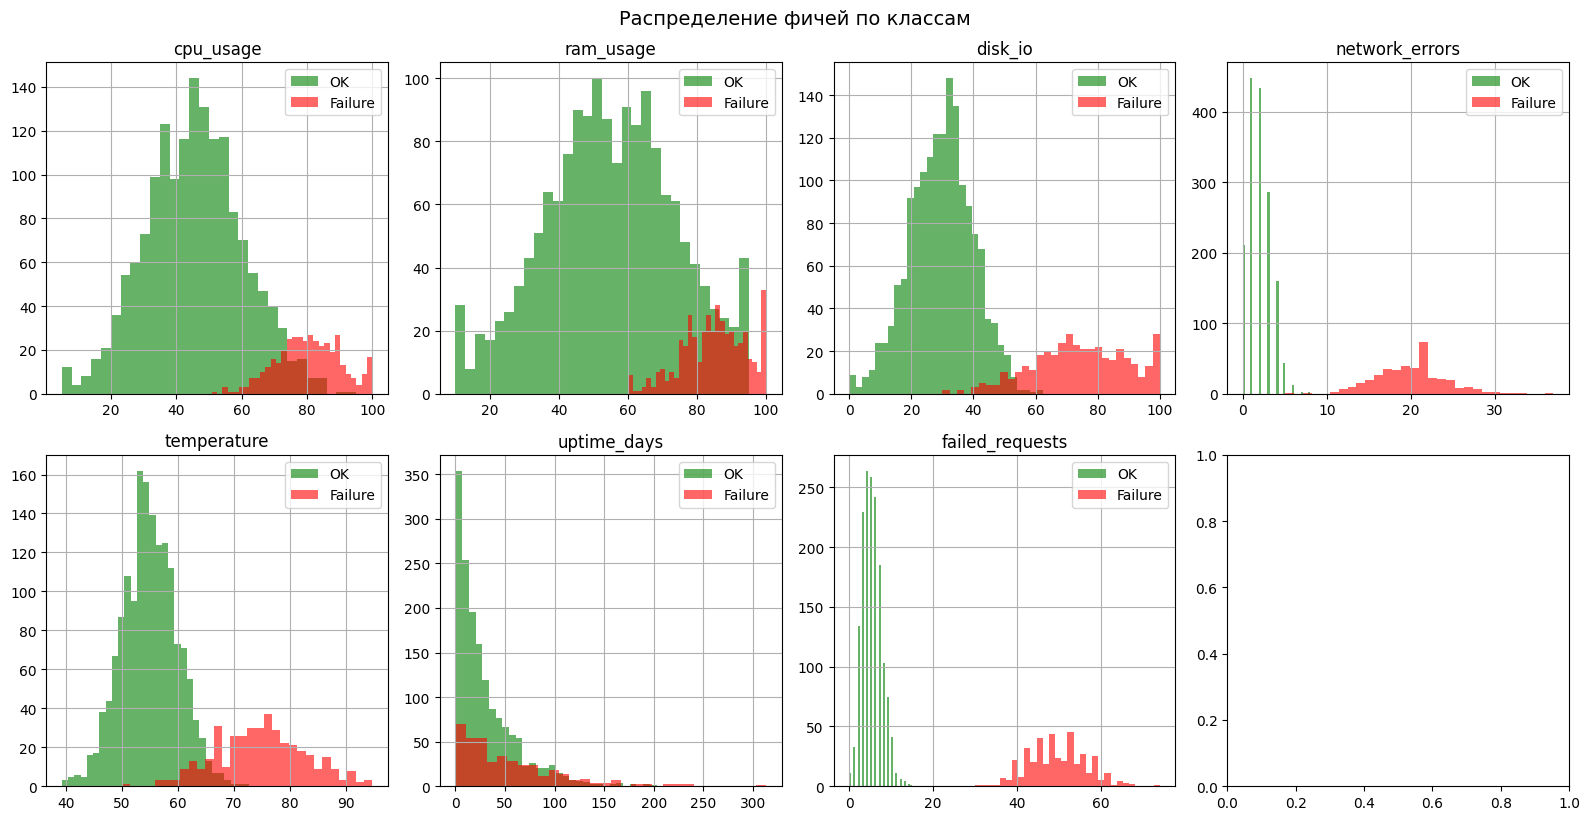

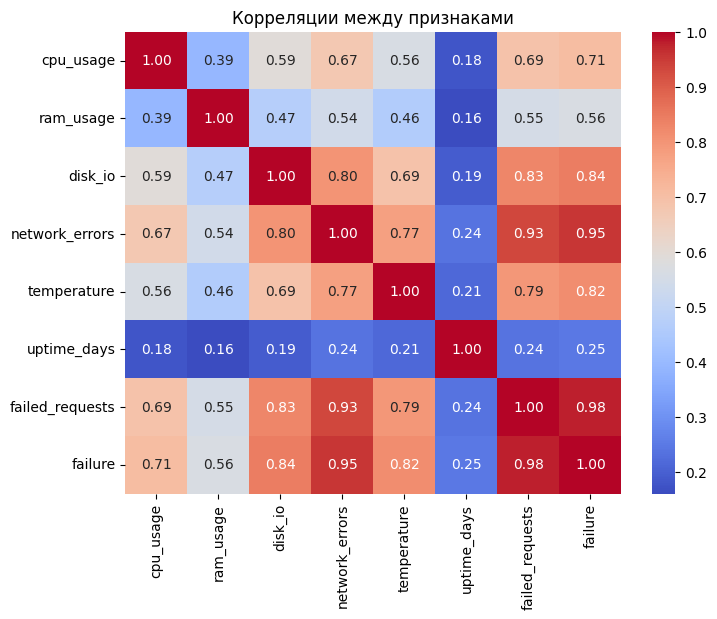

In [3]:
# Смотрим на данные: распределения, корреляции, дисбаланс классов
# Это обязательный этап — понять что в данных перед моделированием

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = ['cpu_usage', 'ram_usage', 'disk_io', 'network_errors', 
            'temperature', 'uptime_days', 'failed_requests']

for i, feat in enumerate(features):
    ax = axes[i // 4][i % 4]
    # Сравниваем распределения для класса 0 и 1
    df[df.failure==0][feat].hist(ax=ax, alpha=0.6, label='OK', bins=30, color='green')
    df[df.failure==1][feat].hist(ax=ax, alpha=0.6, label='Failure', bins=30, color='red')
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.suptitle('Распределение фичей по классам', y=1.02, fontsize=14)
plt.show()

# Корреляционная матрица
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляции между признаками')
plt.show()

In [4]:
# Feature Engineering — создаём новые признаки из существующих
# Это часто дает прирост качества модели

# Новый признак: "индекс нагрузки" — комбинация CPU + RAM
df['load_index'] = (df['cpu_usage'] + df['ram_usage']) / 2

# Признак: сервер "старый" (uptime > 90 дней) — старое железо ломается чаще
df['is_old_server'] = (df['uptime_days'] > 90).astype(int)

# Признак: соотношение ошибок к запросам
df['error_rate'] = df['network_errors'] / (df['failed_requests'] + 1)

FEATURES = ['cpu_usage', 'ram_usage', 'disk_io', 'network_errors',
            'temperature', 'uptime_days', 'failed_requests',
            'load_index', 'is_old_server', 'error_rate']
TARGET = 'failure'

X = df[FEATURES]
y = df[TARGET]

# Делим на train/test — стандартный сплит 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify сохраняет пропорцию классов
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Пропорция классов в train: {y_train.mean():.2f}")

Train: (1600, 10), Test: (400, 10)
Пропорция классов в train: 0.20


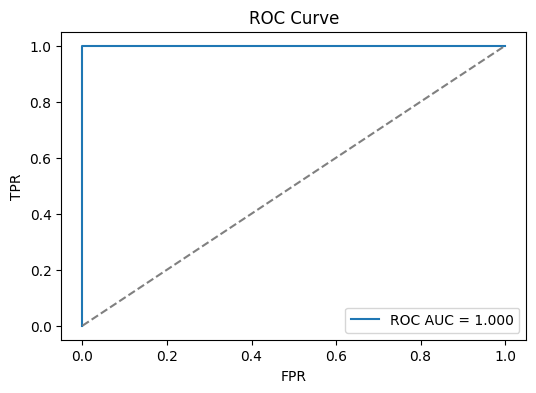

2026/04/30 09:42:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 09:42:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'server-failure-model' already exists. Creating a new version of this model...
2026/04/30 09:42:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: server-failure-model, version 2
Created version '2' of model 'server-failure-model'.



ROC AUC: 1.000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00        80

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Model URI: models:/m-76c0e6a12a1140ce9fe9a89e83998fba
🏃 View run random_forest_v1 at: http://localhost:5000/#/experiments/2/runs/49a2a020ff3f45c290112784af40885e
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [5]:
# MLflow — логируем все: параметры, метрики, артефакты, саму модель
# Всё сохраняется в S3 (настроено в mlflow server)
# Это позволяет сравнивать эксперименты и откатываться к лучшей версии

# Указываем адрес MLflow сервера
# Если запускаете локально: mlflow ui --host 0.0.0.0 --port 5000
MLFLOW_URI = "http://localhost:5000"  # поменяйте на ваш адрес
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("server-failure-prediction")  # создаст эксперимент если нет

# Параметры модели (потом можно менять и сравнивать runs)
params = {
    "n_estimators": 100,
    "max_depth": 6,
    "min_samples_leaf": 5,
    "class_weight": "balanced"  # важно при дисбалансе классов!
}

with mlflow.start_run(run_name="random_forest_v1"):

    # 1. Логируем параметры
    mlflow.log_params(params)
    mlflow.log_param("features_count", len(FEATURES))
    mlflow.log_param("train_size", len(X_train))

    # 2. Создаём Pipeline: скейлер + модель
    # Pipeline гарантирует что на инференсе данные обработаются так же как на трейне
    pipeline = Pipeline([
        ('scaler', StandardScaler()),          # нормализация признаков
        ('model', RandomForestClassifier(**params, random_state=42))
    ])

    # 3. Обучаем
    pipeline.fit(X_train, y_train)

    # 4. Предсказываем
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # 5. Считаем метрики
    roc_auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)

    # 6. Логируем метрики в MLflow
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("precision_failure", report['1']['precision'])
    mlflow.log_metric("recall_failure", report['1']['recall'])
    mlflow.log_metric("f1_failure", report['1']['f1-score'])

    # 7. Сохраняем ROC-кривую как артефакт
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('ROC Curve'); plt.legend()
    plt.savefig('/tmp/roc_curve.png')
    mlflow.log_artifact('/tmp/roc_curve.png')  # загрузится в S3
    plt.show()

    # 8. Сохраняем модель в MLflow (она уйдёт в S3)
    # signature описывает формат входных/выходных данных — нужна для Seldon
    signature = mlflow.models.infer_signature(X_train, pipeline.predict(X_train))
    model_info = mlflow.sklearn.log_model(
        pipeline, 
        artifact_path="model",
        signature=signature,
        registered_model_name="server-failure-model"  # регистрируем в Model Registry
    )

    print(f"\nROC AUC: {roc_auc:.3f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    print(f"\nModel URI: {model_info.model_uri}")

    # Сохраняем URI для следующих ячеек
    model_uri = model_info.model_uri

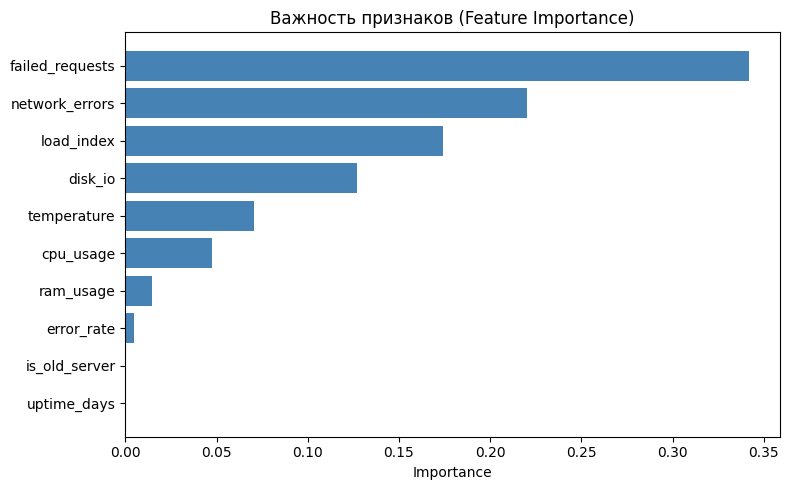

In [6]:
# Важность признаков показывает что модель считает значимым
# Полезно для объяснения бизнесу и дальнейшего feature engineering

feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': pipeline.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.title('Важность признаков (Feature Importance)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [7]:
# Проверяем что модель можно загрузить из MLflow/S3 и она работает
# Именно так Seldon будет её использовать в проде

loaded_model = mlflow.sklearn.load_model(model_uri)

# Симулируем один запрос на инференс (1 сервер)
sample = pd.DataFrame([{
    'cpu_usage': 88,
    'ram_usage': 92,
    'disk_io': 78,
    'network_errors': 50,
    'temperature': 79,
    'uptime_days': 120,
    'failed_requests': 1,
    'load_index': 90,      # (88+92)/2
    'is_old_server': 1,    # uptime > 90
    'error_rate': 35/66    # network_errors / (failed_requests+1)
}])

prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0][1]

print(f"Прогноз: {'⚠️ СБОЙ ОЖИДАЕТСЯ' if prediction == 1 else '✅ Сервер в норме'}")
print(f"Вероятность сбоя: {probability:.1%}")

Прогноз: ⚠️ СБОЙ ОЖИДАЕТСЯ
Вероятность сбоя: 52.2%


In [8]:
import mlflow
mlflow.set_tracking_uri("http://localhost:5000")

client = mlflow.MlflowClient()
latest = client.get_latest_versions("server-failure-model")[0]
print(f"Version: {latest.version}")
print(f"Source (S3 path): {latest.source}")  

Version: 2
Source (S3 path): models:/m-76c0e6a12a1140ce9fe9a89e83998fba


In [9]:
import mlflow
from mlflow.tracking import MlflowClient

# Подключаемся к MLflow
MLFLOW_URI = "http://localhost:5000"  # ваш MLflow
mlflow.set_tracking_uri(MLFLOW_URI)
client = MlflowClient()

MODEL_NAME = "server-failure-model"

# Берём последнюю версию модели
latest = client.get_latest_versions(MODEL_NAME)[0]

print("=" * 60)
print(f"Модель:       {latest.name}")
print(f"Версия:       {latest.version}")
print(f"Run ID:       {latest.run_id}")
print(f"Статус:       {latest.current_stage}")
print()
print(f"source (полный путь как видит MLflow):")
print(f"  {latest.source}")
print("=" * 60)

Модель:       server-failure-model
Версия:       2
Run ID:       49a2a020ff3f45c290112784af40885e
Статус:       None

source (полный путь как видит MLflow):
  models:/m-76c0e6a12a1140ce9fe9a89e83998fba


In [20]:
# latest.source выглядит примерно так:
# mlflow-artifacts:/1/run_id/artifacts/model
# или s3://bucket/mlflow/artifacts/...
# Разбираем и строим правильный путь для Seldon

source = latest.source
run_id = latest.run_id

print(f"Исходный source из MLflow: {source}")
print()

# MLflow хранит артефакты по пути: s3://<bucket>/<experiment_id>/<run_id>/artifacts/model
# Получаем инфо о run чтобы узнать experiment_id
run = client.get_run(run_id)
experiment_id = run.info.experiment_id

print(f"Experiment ID: {experiment_id}")
print(f"Run ID:        {run_id}")
print()

# Если source уже s3:// — берём как есть
if source.startswith("s3://"):
    model_uri_s3 = source
    print(f"✅ URI уже в формате S3: {model_uri_s3}")

# Если source в формате mlflow-artifacts:// — конвертируем
elif source.startswith("mlflow-artifacts"):
    # Получаем bucket из конфига MLflow
    # Смотрим artifact_uri эксперимента
    experiment = client.get_experiment(experiment_id)
    artifact_location = experiment.artifact_location
    print(f"Artifact location эксперимента: {artifact_location}")
    
    # Строим путь вручную
    model_uri_s3 = f"{artifact_location}/{run_id}/artifacts/model"
    print(f"✅ Собранный S3 URI: {model_uri_s3}")

else:
    # Строим из artifact_location эксперимента
    experiment = client.get_experiment(experiment_id)
    artifact_location = experiment.artifact_location
    model_uri_s3 = f"{artifact_location}/{run_id}/artifacts/model"
    print(f"✅ Собранный S3 URI: {model_uri_s3}")

print()
print("=" * 60)
print("Вставьте это в seldon_deployment.yaml:")
print(f"  modelUri: {model_uri_s3}")
print("=" * 60)

Исходный source из MLflow: models:/m-75273b2fd1024b5787b55a7cd4d202a7

Experiment ID: 2
Run ID:        e35a34a8839c4940a9e85346fb1797ab

✅ Собранный S3 URI: s3://mlflow/2/e35a34a8839c4940a9e85346fb1797ab/artifacts/model

Вставьте это в seldon_deployment.yaml:
  modelUri: s3://mlflow/2/e35a34a8839c4940a9e85346fb1797ab/artifacts/model


In [21]:
import subprocess
import requests

MINIO_EXTERNAL = "http://192.168.49.1:9091"  # ваш адрес с хоста

print("=" * 60)
print("ПРОВЕРКА MINIO СНАРУЖИ КЛАСТЕРА (с хоста)")
print("=" * 60)

# Проверяем health endpoint MinIO
for path in ["/minio/health/live", "/health/live", "/"]:
    try:
        r = requests.get(f"{MINIO_EXTERNAL}{path}", timeout=3)
        print(f"  {MINIO_EXTERNAL}{path} → HTTP {r.status_code} ✅")
        break
    except Exception as e:
        print(f"  {MINIO_EXTERNAL}{path} → ❌ {e}")

print()

ПРОВЕРКА MINIO СНАРУЖИ КЛАСТЕРА (с хоста)
  http://192.168.49.1:9091/minio/health/live → HTTP 200 ✅



In [22]:
# Seldon работает внутри кластера и не видит 192.168.49.1
# Ему нужен internal DNS адрес сервиса MinIO
# Формат: http://<service-name>.<namespace>.svc.cluster.local:<port>

print("=" * 60)
print("ИЩЕМ MINIO ВНУТРИ КЛАСТЕРА")
print("=" * 60)

# Получаем все сервисы через kubectl
result = subprocess.run(
    ["kubectl", "get", "svc", "-A", "-o", 
     "custom-columns=NAMESPACE:.metadata.namespace,NAME:.metadata.name,PORT:.spec.ports[*].port,IP:.spec.clusterIP"],
    capture_output=True, text=True
)

print("Все сервисы в кластере:")
print(result.stdout)

# Фильтруем — ищем MinIO
print("\nСервисы похожие на MinIO:")
for line in result.stdout.split('\n'):
    if any(x in line.lower() for x in ['minio', 's3', '9000', '9090', '9091']):
        print(f"  👉 {line}")

ИЩЕМ MINIO ВНУТРИ КЛАСТЕРА
Все сервисы в кластере:
NAMESPACE              NAME                        PORT                    IP
default                kubernetes                  443                     10.96.0.1
istio-system           istiod                      15010,15012,443,15014   10.101.62.204
kube-system            kube-dns                    53,53,9153              10.96.0.10
kubernetes-dashboard   dashboard-metrics-scraper   8000                    10.105.205.168
kubernetes-dashboard   kubernetes-dashboard        80                      10.97.152.11
seldon-system          seldon-webhook-service      443                     10.108.87.17


Сервисы похожие на MinIO:


In [17]:
# Seldon Core разворачивает модель как REST/gRPC микросервис в Kubernetes
# Достаточно указать model_uri — Seldon сам скачает модель из S3

# Получаем актуальный URI из Model Registry
client = mlflow.MlflowClient()
latest = client.get_latest_versions("server-failure-model", stages=["None"])[0]
model_uri_for_seldon = f"models:/server-failure-model/{latest.version}"

print("Seldon Core манифест (применить через kubectl):\n")

seldon_manifest = f"""
apiVersion: machinelearning.seldon.io/v1
kind: SeldonDeployment
metadata:
  name: server-failure-model
  namespace: seldon
spec:
  predictors:
  - name: default
    replicas: 1
    graph:
      name: classifier
      implementation: MLFLOW_SERVER    # Seldon умеет в MLflow из коробки
      modelUri: {model_uri_for_seldon}
      envSecretRefName: seldon-s3-secret  # секрет с AWS_ACCESS_KEY и т.д.
    componentSpecs:
    - spec:
        containers:
        - name: classifier
          resources:
            requests:
              memory: "1Gi"
              cpu: "500m"
            limits:
              memory: "2Gi"
              cpu: "1"
"""

print(seldon_manifest)
print("\nКоманда для деплоя:")
print("kubectl apply -f seldon_deployment.yaml")
print("\nПроверка статуса:")
print("kubectl get sdep server-failure-model -n seldon")

Seldon Core манифест (применить через kubectl):


apiVersion: machinelearning.seldon.io/v1
kind: SeldonDeployment
metadata:
  name: server-failure-model
  namespace: seldon
spec:
  predictors:
  - name: default
    replicas: 1
    graph:
      name: classifier
      implementation: MLFLOW_SERVER    # Seldon умеет в MLflow из коробки
      modelUri: models:/server-failure-model/1
      envSecretRefName: seldon-s3-secret  # секрет с AWS_ACCESS_KEY и т.д.
    componentSpecs:
    - spec:
        containers:
        - name: classifier
          resources:
            requests:
              memory: "1Gi"
              cpu: "500m"
            limits:
              memory: "2Gi"
              cpu: "1"


Команда для деплоя:
kubectl apply -f seldon_deployment.yaml

Проверка статуса:
kubectl get sdep server-failure-model -n seldon


In [ ]:
import requests

# После деплоя Seldon поднимает REST API
# Формат запроса — Seldon Protocol (ndarray или dataframe)

SELDON_URL = "http://your-seldon-gateway/seldon/seldon/server-failure-model/api/v1.0/predictions"

payload = {
    "data": {
        "names": FEATURES,
        "ndarray": [[88, 92, 78, 35, 79, 120, 65, 90, 1, 0.53]]
    }
}

# Раскомментируйте когда Seldon задеплоен:
# response = requests.post(SELDON_URL, json=payload)
# print(response.json())

# Для демо — имитируем ответ Seldon
mock_response = {
    "data": {
        "names": ["failure_probability"],
        "ndarray": [[0.15, 0.85]]  # [P(class=0), P(class=1)]
    },
    "meta": {"requestPath": {"classifier": "server-failure-model:v1"}}
}
print("Mock ответ от Seldon:")
print(mock_response)
print(f"\nВероятность сбоя: {mock_response['data']['ndarray'][0][1]:.1%}")